In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
base_path = r'D:\Dsoft\Projects\ML\data\road_accidents' + '\\'
sample_submission = base_path + r'sample_submission.csv'
train_path = base_path + r'train.csv'
test_path = base_path + r'test.csv'

In [23]:
df = pd.read_csv(train_path)

In [24]:
cat_cols = ['road_type', \
        'lighting', \
        'weather', \
        'road_signs_present', \
        'public_road', \
        'time_of_day', \
        'holiday', \
        'school_season']

In [25]:
from sklearn.preprocessing import OneHotEncoder

# Separate categorical and numerical columns
categorical_cols = cat_cols
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['id', 'accident_risk']]

# One-hot encode categorical columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_features = ohe.fit_transform(df[categorical_cols])
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
df_ohe = pd.DataFrame(ohe_features, columns=ohe_feature_names, index=df.index)

# Concatenate numerical columns and encoded categorical columns
df_encoded = pd.concat([df[numerical_cols + ['id', 'accident_risk']], df_ohe], axis=1)

df_encoded.head()

,num_lanes,curvature,speed_limit,num_reported_accidents,id,accident_risk,road_type_highway,road_type_rural,road_type_urban,lighting_daylight,...,road_signs_present_True,public_road_False,public_road_True,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,holiday_False,holiday_True,school_season_False,school_season_True
0,2,0.06,35,1,0,0.13,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,4,0.99,35,0,1,0.35,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,4,0.63,70,2,2,0.30,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,4,0.07,35,1,3,0.21,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
4,1,0.58,60,1,4,0.56,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0


In [4]:
def cat_to_num(df):
    cat_cols = ['road_type', \
            'lighting', \
            'weather', \
            'road_signs_present', \
            'public_road', \
            'time_of_day', \
            'holiday', \
            'school_season']
    for i in cat_cols:
        if i not in df.columns:
            print(f"Necessary columns do not exist: {i}")
            raise;
    
    # Boolean columns True:1, False:0
    bool_cols = ['road_signs_present', 'public_road' , 'holiday' , 'school_season']
    for i in bool_cols:
        df[i] = df[i].apply(lambda x: 1 if x else 0)
    
    # road_type ['urban' 'rural' 'highway']
    road_mapping = {'highway': 3, 'urban':2, 'rural': 1}
    df['road_type'] = df['road_type'].map(road_mapping)  

    # lighting ['daylight' 'dim' 'night']
    light_mapping = {'daylight': 1, 'dim':2, 'night': 3}
    df['lighting'] = df['lighting'].map(light_mapping)  

    # weather ['rainy' 'clear' 'foggy']
    weather = {'rainy': 3, 'clear':1, 'foggy': 2}
    df['weather'] = df['weather'].map(weather) 

    # time_of_day ['afternoon' 'evening' 'morning']
    time_of_day = {'afternoon': 2, 'evening':3, 'morning': 1}
    df['time_of_day'] = df['time_of_day'].map(time_of_day) 
    
    return df
    

In [9]:
df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [5]:
cat_cols = ['road_type', \
        'lighting', \
        'weather', \
        'road_signs_present', \
        'public_road', \
        'time_of_day', \
        'holiday', \
        'school_season']

In [12]:
prep_df = cat_to_num(df)

Text(0.5, 1.0, 'Categorical Features Correlation with Accident Severity')

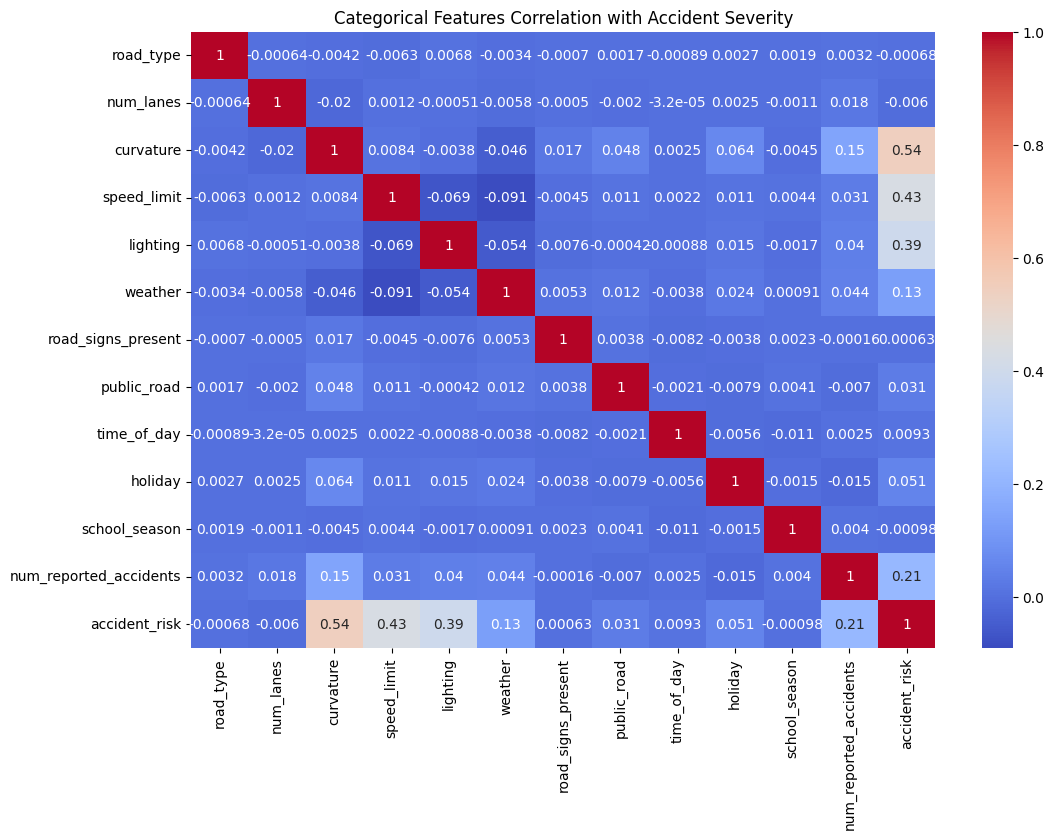

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(prep_df[['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk']].corr(), annot=True, cmap='coolwarm')
plt.title('Categorical Features Correlation with Accident Severity')

Text(0.5, 1.0, 'Categorical Features Correlation with Accident Severity')

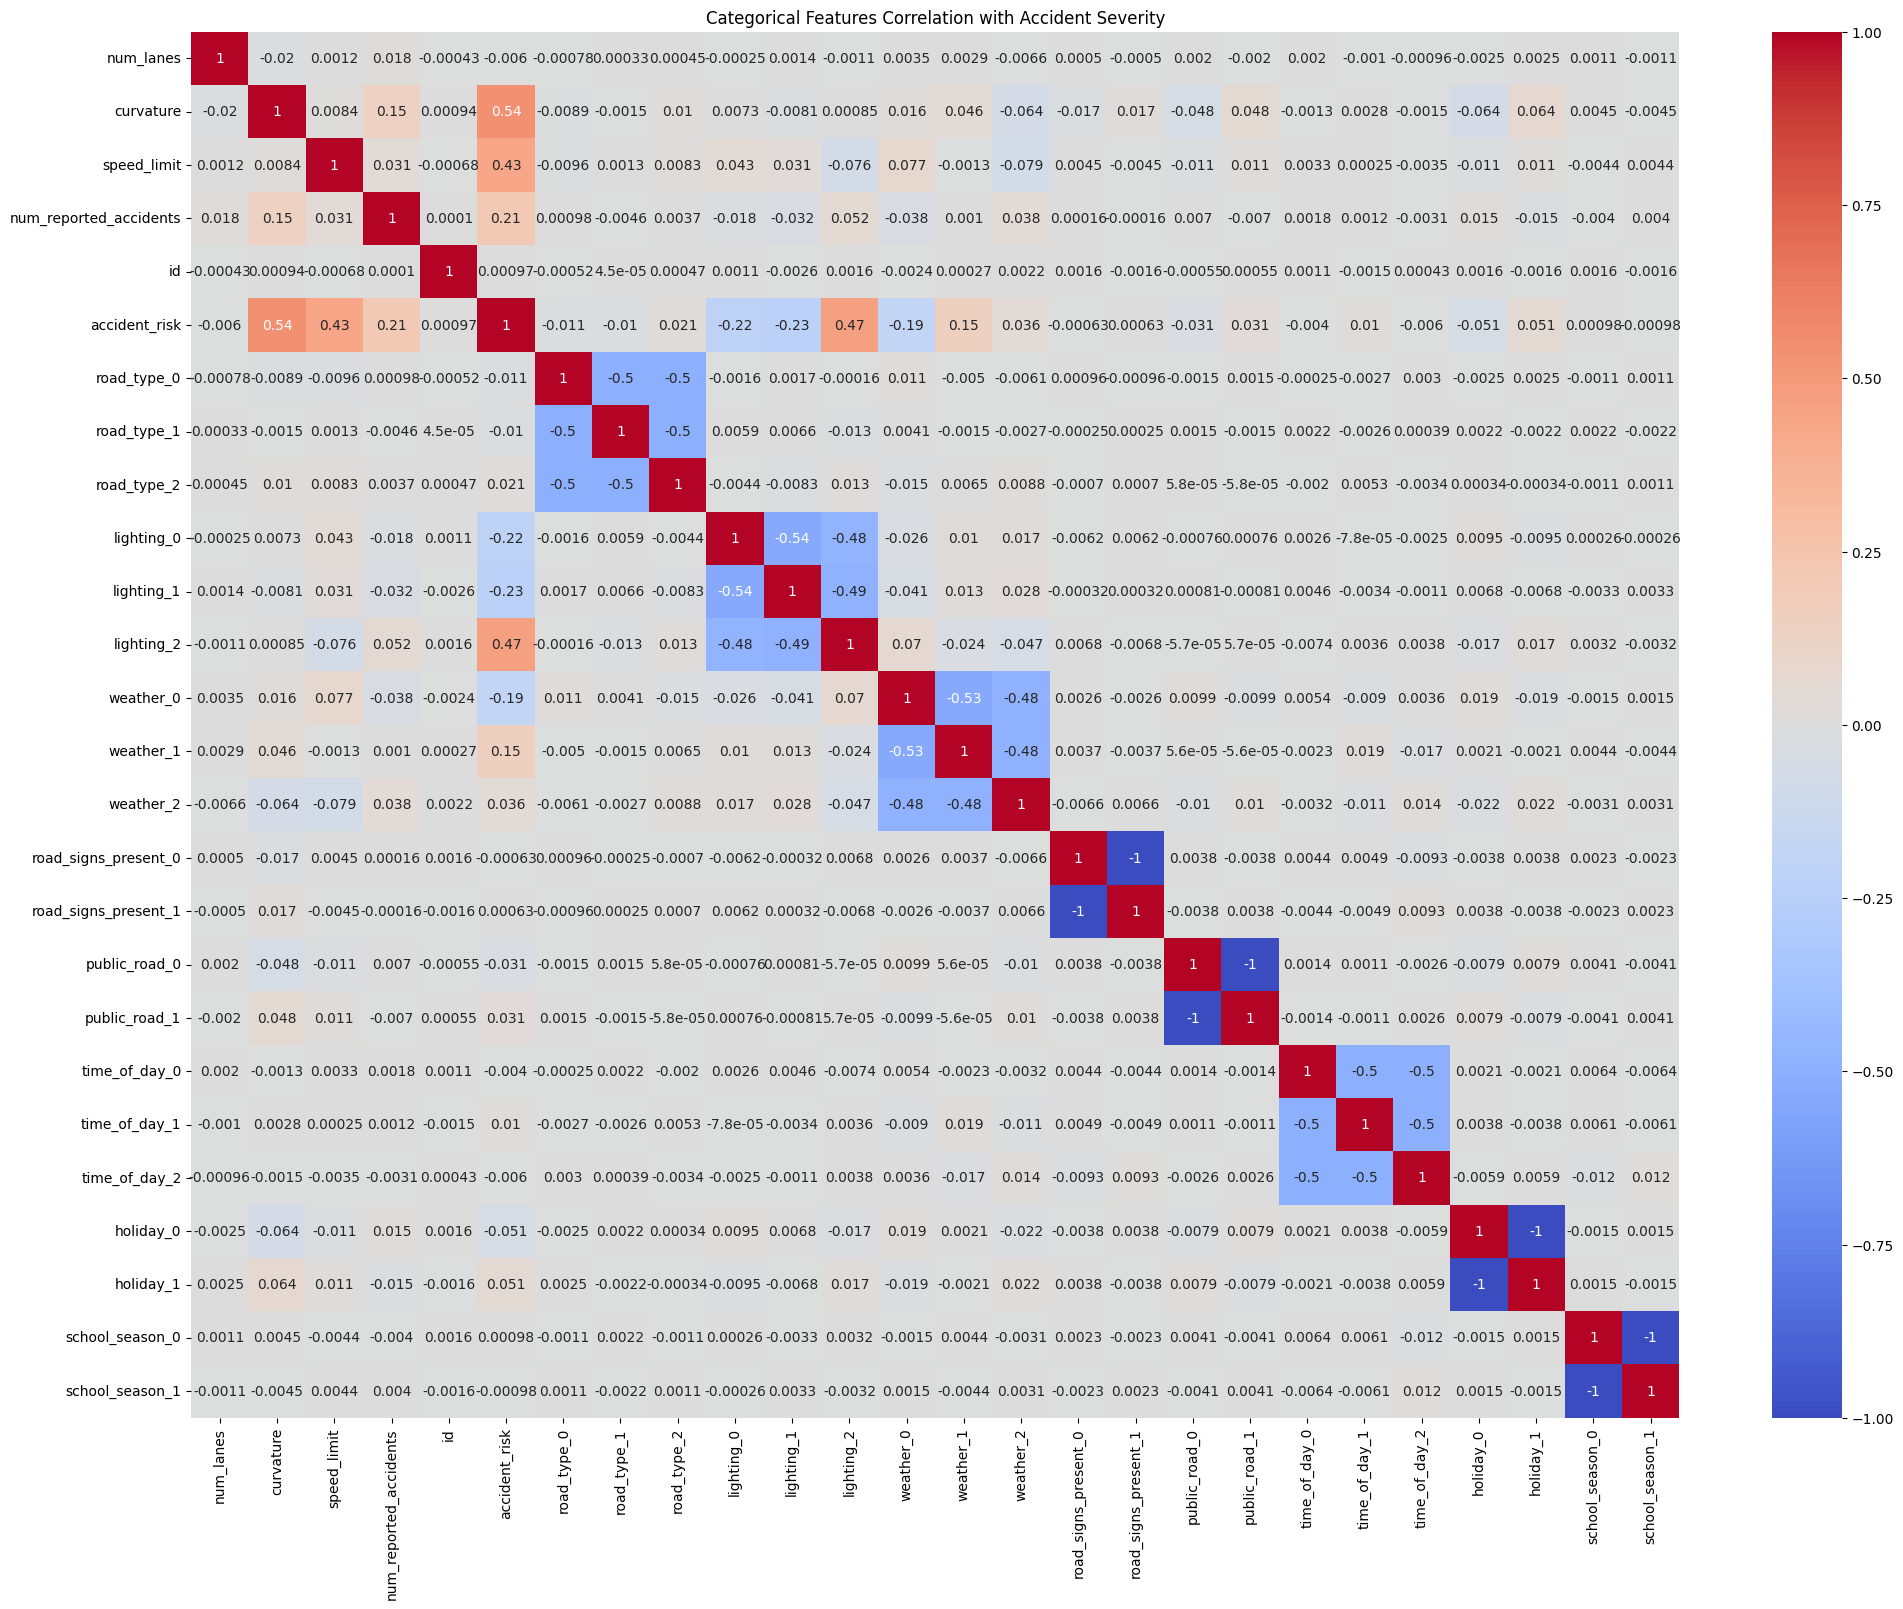

In [21]:
plt.figure(figsize=(24,18))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Categorical Features Correlation with Accident Severity')

In [18]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# columns to scale (keep id and target unchanged)
exclude_cols = ['id', 'accident_risk']
feature_cols = [c for c in prep_df.columns if c not in exclude_cols]

scaler = MinMaxScaler()
prep_norm = prep_df.copy()
prep_norm[feature_cols] = scaler.fit_transform(prep_df[feature_cols])

# quick sanity checks
print("Normalized dataframe shape:", prep_norm.shape)
print(prep_norm[feature_cols].agg(['min', 'max']).T)

# # persist scaler for later use
# joblib.dump(scaler, base_path + 'minmax_scaler.pkl')

Normalized dataframe shape: (517754, 14)
                        min  max
road_type               0.0  1.0
num_lanes               0.0  1.0
curvature               0.0  1.0
speed_limit             0.0  1.0
lighting                0.0  1.0
weather                 0.0  1.0
road_signs_present      0.0  1.0
public_road             0.0  1.0
time_of_day             0.0  1.0
holiday                 0.0  1.0
school_season           0.0  1.0
num_reported_accidents  0.0  1.0


In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(prep_norm[['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk']], annot=True)
plt.title('Features Correlation with Accident Severity')

In [26]:
    # Split prep_norm into train / validation / test sets.
    # If prep_norm isn't available, fall back to prep_df.
def split_data(df_encoded):    
    df_for_split = df_encoded.copy()

    # features (exclude id and target) and target
    feature_cols = [c for c in df_for_split.columns if c not in ('id', 'accident_risk')]
    X = df_for_split[feature_cols]
    y = df_for_split['accident_risk']

    # Use binned target for stratified splits (preserves distribution of continuous target)
    y_binned = pd.qcut(y, q=10, labels=False, duplicates='drop')

    # first split: hold out test set (15%)
    TEST_SIZE = 0.15
    RANDOM_STATE = 42
    X_train_val, X_test, y_train_val, y_test, ybv_train_val, ybv_test = train_test_split(
        X, y, y_binned, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_binned
    )

    # second split: from remaining, take validation set so that val is 15% of original
    VAL_FRACTION_OF_REMAINING = 0.15 / (1 - TEST_SIZE)  # 0.15 / 0.85
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=VAL_FRACTION_OF_REMAINING,
        random_state=RANDOM_STATE,
        stratify=pd.qcut(y_train_val, q=10, labels=False, duplicates='drop')
    )

    # quick sanity checks
    print("Shapes:")
    print("  X_train:", X_train.shape, "y_train:", y_train.shape)
    print("  X_val:  ", X_val.shape,  "y_val:  ", y_val.shape)
    print("  X_test: ", X_test.shape, "y_test: ", y_test.shape)

    # Optionally inspect target distribution across splits
    print("\nTarget summary (median, min, max):")
    print("  train:", y_train.median(), y_train.min(), y_train.max())
    print("  val:  ", y_val.median(),   y_val.min(),   y_val.max())
    print("  test: ", y_test.median(),  y_test.min(),  y_test.max())
    return X_train, X_val, X_test, y_train, y_val, y_test

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [28]:

X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_encoded)

Shapes:
  X_train: (362427, 24) y_train: (362427,)
  X_val:   (77663, 24) y_val:   (77663,)
  X_test:  (77664, 24) y_test:  (77664,)

Target summary (median, min, max):
  train: 0.34 0.0 1.0
  val:   0.34 0.0 1.0
  test:  0.34 0.0 1.0


In [30]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [36]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist')
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:

y_pred = model.predict(X_test)

print("RandomForestRegressor Results")
print('RMSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))


y_pred_linear = linear_model.predict(X_test)

print("LinearRegression Results")
print('RMSE (Linear):', mean_squared_error(y_test, y_pred_linear))
print('R2 (Linear):', r2_score(y_test, y_pred_linear))


y_pred_gb = gb_model.predict(X_test)

print("GradientBoostingRegressor Results")
print('RMSE (GB):', mean_squared_error(y_test, y_pred_gb))
print('R2 (GB):', r2_score(y_test, y_pred_gb))

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results")
print('RMSE (XGBoost):', mean_squared_error(y_test, y_pred_xgb))
print('R2 (XGBoost):', r2_score(y_test, y_pred_xgb))

RandomForestRegressor Results
RMSE: 0.003503242102838136
R2: 0.872501338428711
LinearRegression Results
RMSE (Linear): 0.005398722976564201
R2 (Linear): 0.803516304754258
GradientBoostingRegressor Results
RMSE (GB): 0.003227874378196597
R2 (GB): 0.8825232025480318
XGBoost Results
RMSE (XGBoost): 0.0031512299847652157
R2 (XGBoost): 0.8853126351058124


C:\Users\16yas\AppData\Local\Temp\ipykernel_23840\114650824.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi.values[:top_n], y=fi.index[:top_n], palette='viridis')


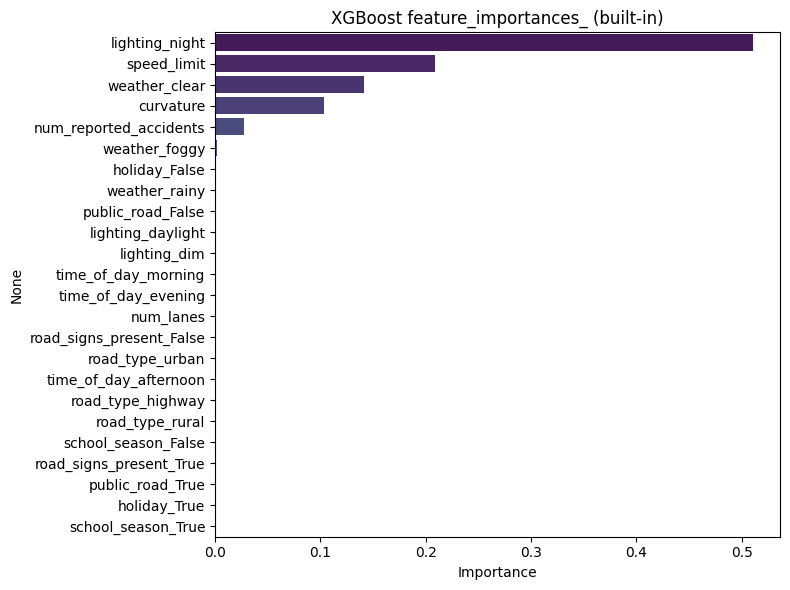

Computing permutation importance on validation set (this may take a bit)...


C:\Users\16yas\AppData\Local\Temp\ipykernel_23840\114650824.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_series.values[:top_n2], y=perm_series.index[:top_n2], palette='magma')


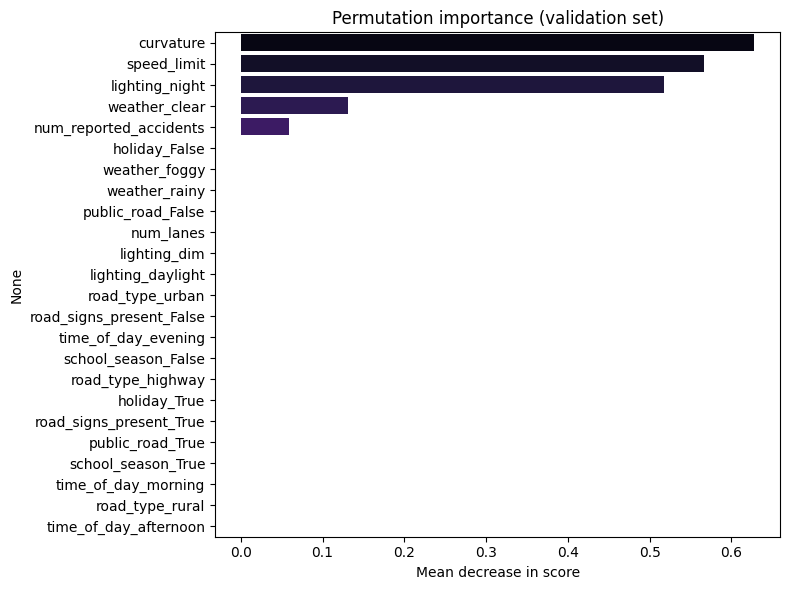


Top features (built-in XGBoost importance):
lighting_night            0.510864
speed_limit               0.209109
weather_clear             0.141043
curvature                 0.103074
num_reported_accidents    0.027205
weather_foggy             0.001554
holiday_False             0.000932
weather_rainy             0.000874
public_road_False         0.000737
lighting_daylight         0.000661

Top features (permutation importance):
curvature                 0.628157
speed_limit               0.566991
lighting_night            0.517903
weather_clear             0.131321
num_reported_accidents    0.059326
holiday_False             0.000596
weather_foggy             0.000460
weather_rainy             0.000385
public_road_False         0.000364
num_lanes                 0.000243


,xgb_builtin,permutation_mean
lighting_night,0.510864,0.517903
speed_limit,0.209109,0.566991
weather_clear,0.141043,0.131321
curvature,0.103074,0.628157
num_reported_accidents,0.027205,0.059326
weather_foggy,0.001554,0.000460
holiday_False,0.000932,0.000596
weather_rainy,0.000874,0.000385
public_road_False,0.000737,0.000364
lighting_daylight,0.000661,0.000095


In [38]:
# Visualize XGBoost feature importances and permutation importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Ensure feature names are available
try:
    feature_names = X_train.columns.tolist()
except Exception as e:
    raise RuntimeError("X_train is not defined. Run the training / split cells first.") from e

# 1) XGBoost built-in importance (gain/weight)
if hasattr(xgb_model, 'feature_importances_'):
    imp = xgb_model.feature_importances_
    fi = pd.Series(imp, index=feature_names).sort_values(ascending=False)
    top_n = min(30, len(fi))
    plt.figure(figsize=(8, max(4, top_n*0.25)))
    sns.barplot(x=fi.values[:top_n], y=fi.index[:top_n], palette='viridis')
    plt.title('XGBoost feature_importances_ (built-in)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    # save top features to csv
    try:
        fi.head(100).to_csv(base_path + 'xgb_feature_importances_builtin.csv')
    except Exception:
        pass
else:
    print('xgb_model has no feature_importances_ attribute')

# 2) Permutation importance on validation set (more reliable, model-agnostic)
try:
    if 'X_val' in globals() and 'y_val' in globals():
        print('Computing permutation importance on validation set (this may take a bit)...')
        perm = permutation_importance(xgb_model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
        perm_series = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
        top_n2 = min(30, len(perm_series))
        plt.figure(figsize=(8, max(4, top_n2*0.25)))
        sns.barplot(x=perm_series.values[:top_n2], y=perm_series.index[:top_n2], palette='magma')
        plt.title('Permutation importance (validation set)')
        plt.xlabel('Mean decrease in score')
        plt.tight_layout()
        plt.show()
        # persist results
        try:
            perm_series.to_csv(base_path + 'xgb_permutation_importances_validation.csv')
        except Exception:
            pass
    else:
        print('X_val / y_val not found: skip permutation importance (run split_data first).')
except Exception as e:
    print('Permutation importance failed:', e)

# 3) Print top 10 features (both methods if available)
print('\nTop features (built-in XGBoost importance):')
try:
    print(fi.head(10).to_string())
except NameError:
    print('built-in importances not available')

print('\nTop features (permutation importance):')
try:
    print(perm_series.head(10).to_string())
except NameError:
    print('permutation importances not available')

# Optional: show a compact dataframe of top features side-by-side if both exist
try:
    both = pd.concat([fi, perm_series], axis=1)
    both.columns = ['xgb_builtin', 'permutation_mean']
    display(both.head(20))
except Exception:
    pass
